# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [4]:
total_bytes = df.memory_usage().sum()
total_megabytes = total_bytes / (1024 * 1024)

In [5]:
print(f'В датасеті {df.shape[0]} рядків та {df.shape[1]} колонок. Oбсяг файлу {total_megabytes.round(2)} Mb')

В датасеті 10886 рядків та 19 колонок. Oбсяг файлу 1.42 Mb


Дані охоплюють період з 01.01.2011 по 19.12.2012. Рівень деталізації - погодинний, тобто один рядок відповідає одній годині спостереження.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
daily_rent = df['count'].resample('D').sum()
daily_rent

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Freq: D, Name: count, Length: 719, dtype: int64

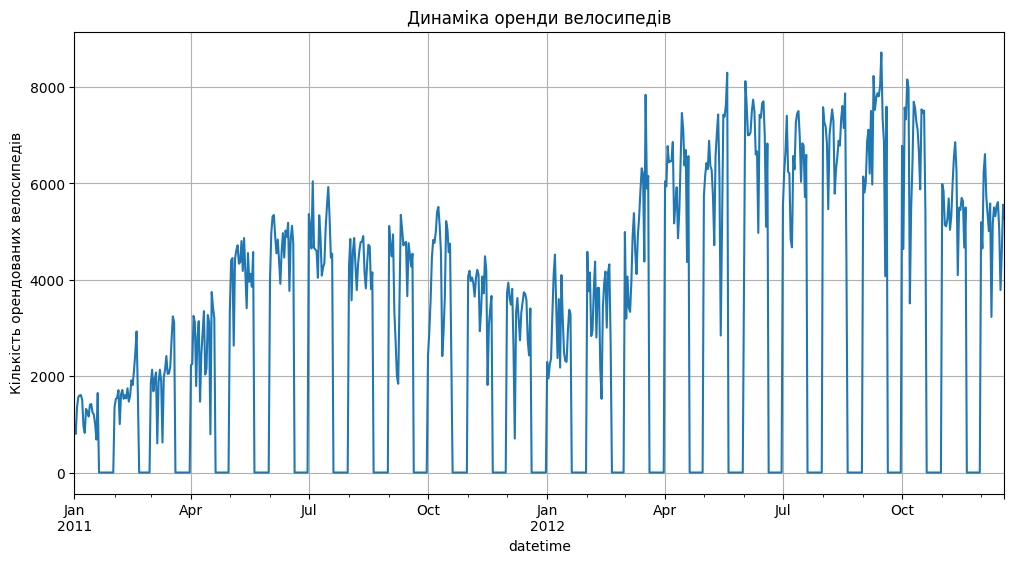

In [7]:
daily_rent.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    ylabel='Кількість орендованих велосипедів',
    grid=True 
);

In [8]:
days_per_month = df.groupby(['year', 'month'])['day'].nunique()
print(days_per_month)

year  month
2011  1        19
      2        19
      3        19
      4        19
      5        19
      6        19
      7        19
      8        19
      9        19
      10       19
      11       19
      12       19
2012  1        19
      2        19
      3        19
      4        19
      5        19
      6        19
      7        19
      8        19
      9        19
      10       19
      11       19
      12       19
Name: day, dtype: int64


In [9]:
daily_rental1= df.groupby('date')['count'].resample('D').sum()

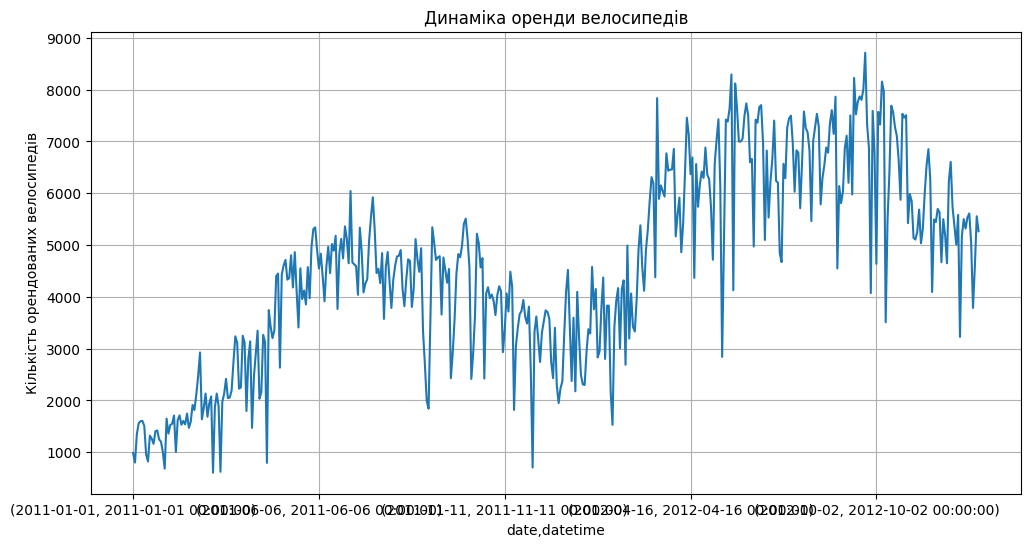

In [10]:
daily_rental1.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    ylabel='Кількість орендованих велосипедів',
    grid=True 
    )
plt.show()

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Заломи спостерігаються регулярно, кожного місяця. Cхоже, що у датасеті відсуня інформація за деякі дати, тобто лише за перші 19 днів. 
Заломи можна  прибрати шляхом групування по даті.

2. Які загальні тенденції ви бачите на графіку?
У 2012 році оренд більше, ніж у 2011. Це може свідчити про зростання популярності сервісу.

3. Чи помітні якісь сезонні коливання?
Так, сезонність добре помітна. З середини весни почитається зростання кількість орендованих велосипедів. Ця тенденція триває до середини осені, після чого бачимо спад. Логічно, що хороша погода сприяє збільшенню попиту.

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
Так, бачимо як різкі спади, що може бути пов'язано з поганою погодою, святами, так і різкі підйоми, хоч і менш різкі, що також може бути пов'язано вже з хорошою погодою, або, наприклад вихідними.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [11]:
rental_season_mean= df.groupby('season')['count'].mean()

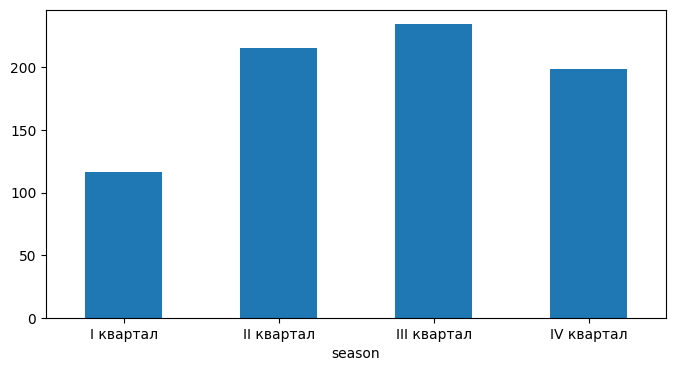

In [12]:
bp = rental_season_mean.plot.bar(figsize=(8, 4))
plt.xticks(rotation=0)
bp.set_xticklabels(['I квартал', 'II квартал','III квартал','IV квартал'])
plt.show()

В який квартал найбільша середня кількість оренди велосипедів?
Найбільша середня кількість оренд спостерігається у III кварталі. Найменша - у I кварталі.

Як ви можете пояснити таку сезонну закономірність?
Влітку та навесні погодні умови є найбільш сприятливими для користування велосипедами. Натомість взимку низькі температури та несприятливі погодні умови знижують попит. Таким чином, сезонність пов’язана з погодними факторами.

У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?
Співвідношення становить 234 / 116 = 2,02. Отже, у 3 кварталі оренда приблизно у 2 рази вища, ніж у 1 кварталі.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


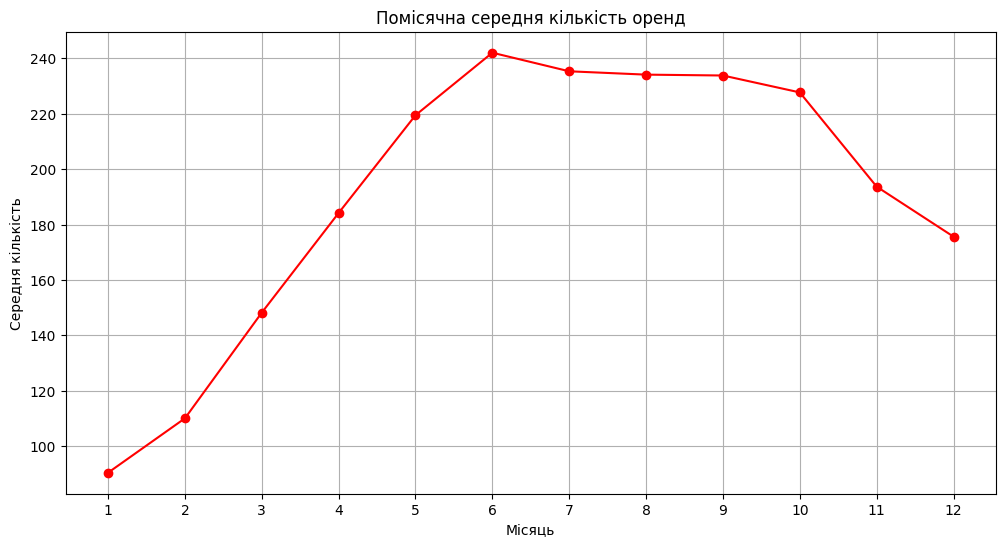

In [13]:
month_rent_mean= df.groupby('month')['count'].mean()

month_rent_mean.plot (
    figsize=(12, 6),
    xlabel='Місяць',
    ylabel='Середня кількість',
    marker='o',
    color='red',
    grid=True,
    title='Помісячна середня кількість оренд'
)

plt.xticks(range(1,13))

plt.show()

1. В які місяці спостерігається пік та спад оренди?
    Пік припадає на 5–10 місяці, спад спостерігається у січні та лютому (1–2 місяці).

2. Чи збігається ця закономірність з результатами з попереднього завдання?

    Так, вона повністю підтверджує сезонний графік. Якщо раніше ми бачили, що 3-й квартал (літо-осінь) найпопулярніший, то зараз ми бачимо конкретні місяці цього кварталу, які формують цей пік.

4. Як може вплинути клімат на оренду велосипедів протягом року?

   Клімат є визначальним фактором. Погодні умови маютю пряму кореляцію з орендою: чим тепліше, тим більше людей обирають велосипед. Опади різко знижують кількість оренд через дискомфорт та небезпеку на дорогах.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

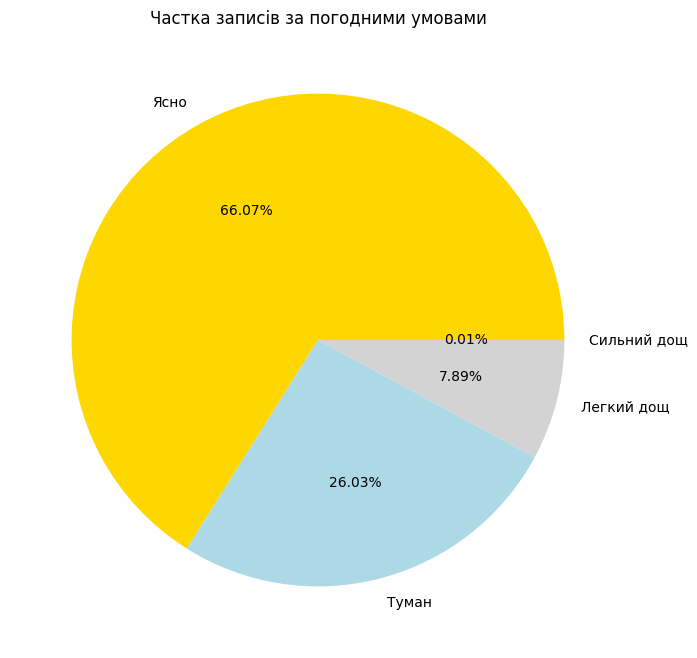

In [14]:
weather_impact = df['weather'].value_counts()
weather_impact

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

<Axes: title={'center': 'Частка записів за погодними умовами'}>

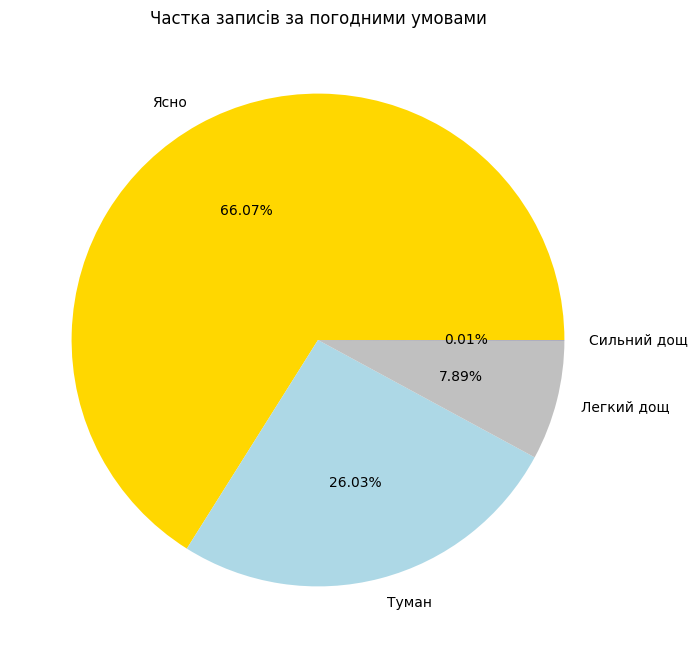

In [15]:
weather_impact.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=['gold', 'lightblue', 'silver', 'darkblue'],
)

1. Яка погода переважає в датасеті?
    У датасеті переважає ясна погода. Її частка становить приблизно 66% від усіх записів.
2. Чи є дні із сильним дощем? Яка їх частка?
    Так, такі дні є, але за період спостережень сильний дощ траплявся дуже мало. Частка складає всього 0.01%. 
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?
   Погодні умови суттєво впливають на попит. За ясної погоди оренда є значно вищою, тоді як під час дощу чи інших несприятливих умов кількість оренд значно зменшується.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [16]:
weather_type = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

df['weather_name'] = df['weather'].map(weather_type)

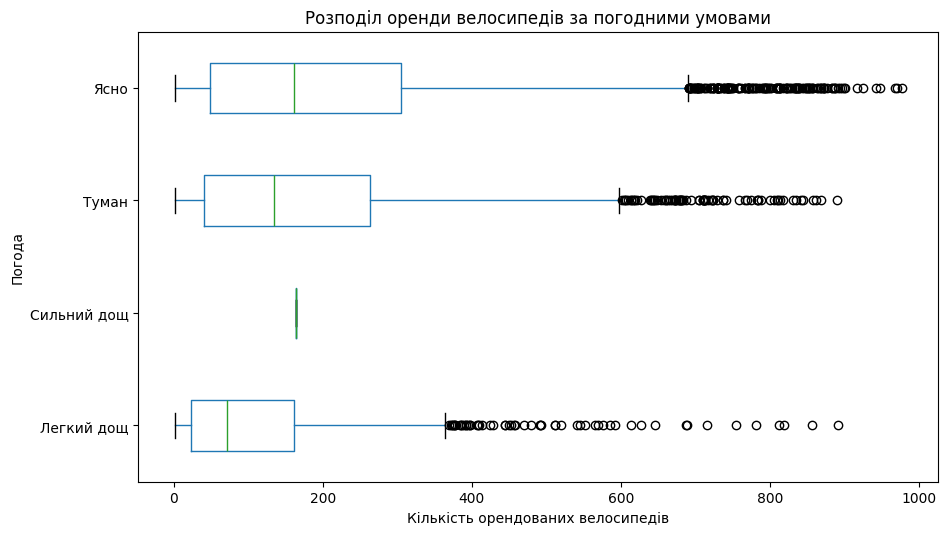

In [17]:
df.boxplot(
    column='count',
    by='weather_name',
    figsize=(10, 6),
    grid = False,
    vert = False
)
plt.title('Розподіл оренди велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погода')

plt.show()

1. При якій погоді найбільший розкид у кількості оренди?
    Найбільший розкид спостерігається при погоді "Ясно".
2. Чи є викиди (outliers) в даних? При якій погоді?
    Ясно, туман та легкий дощ - бачимо викиди в даних при кожній погоді.  При сильному дощі викидів майже немає через малу кількість спостережень.
3. При якій погоді медіанне значення оренди найвище?
    Найвище медіанне значення оренди спостерігається за ясної погоди, що свідчить про найбільший типовий рівень попиту в сприятливих погодних умовах.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

In [19]:
grouped_avg_rentals = df.groupby(['temp', 'season'])['count'].mean().reset_index()

,temp,season,count
0,0.82,1,77.714286
1,1.64,1,91.500000
2,2.46,1,43.000000
3,3.28,1,19.272727
4,4.10,1,50.272727
...,...,...,...
129,37.72,3,363.481481
130,38.54,2,104.000000
131,38.54,3,261.333333
132,39.36,3,317.833333


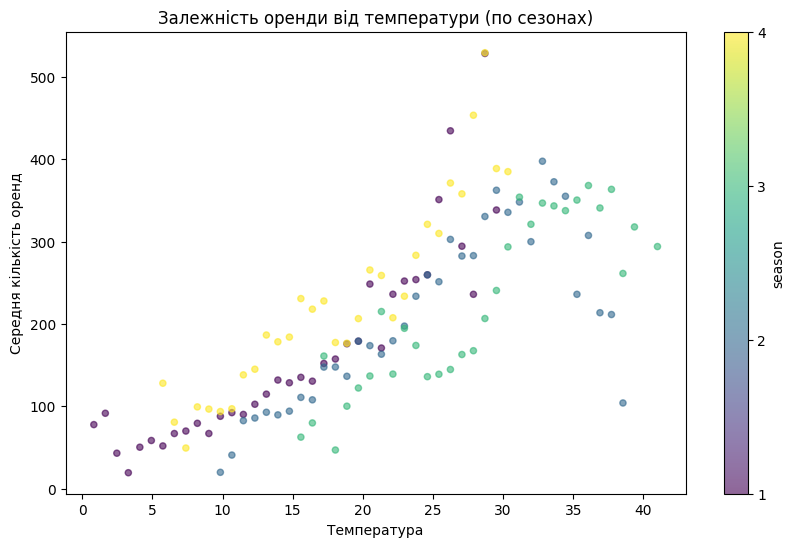

In [20]:
ax = grouped_avg_rentals.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    alpha=0.6,
    figsize=(10, 6),
    title='Залежність оренди від температури (по сезонах)'
)
ax.set_xlabel('Температура')
ax.set_ylabel('Середня кількість оренд')
cbar = ax.figure.axes[-1]
cbar.set_yticks([1, 2, 3, 4])
#cbar.set_ticklabels(['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал'])

Так, очевидна залежність між температорую та кількість орендованих велосипедів. При низькій температурі, можемо спостерігати на графіку, що орендують мало велосипедів. Чим більша температура, тим більше велосипедів орендують. Тобто, спостерігаємо позитивну кореляцію.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [ ]:
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday_cat'] = pd.Categorical(df['weekday'], categories=ordered_days, ordered=True)